# Hazard assessment for relative drought — Kazakhstan

- Adapted from the CLIMAAX [Handbook](https://handbook.climaax.eu/) and [DROUGHTS](https://github.com/CLIMAAX/DROUGHTS) GitHub repository.
- Methodology: Carrão et al. (2016) [doi:10.1016/j.gloenvcha.2016.04.012](https://doi.org/10.1016/j.gloenvcha.2016.04.012)

**Key differences from the original CLIMAAX workflow:**
- Spatial units are Kazakhstan **districts** (admin level 3) rather than EU NUTS3 regions.
- Climate data is downloaded directly from ISIMIP3b, clipped to Kazakhstan, and aggregated on the fly — no pre-hosted sample data is required.
- The global WASP median is computed from Kazakhstan districts only (not EU-wide). dH values therefore express *relative* drought severity within Kazakhstan. See the Limitations section.
- SSP5-8.5 is not included; SSP1-2.6 and SSP3-7.0 are processed.

In this workflow, drought hazard (dH) for each Kazakhstan **district** is estimated as the probability that a drought event exceeds the Kazakhstan-wide median precipitation deficit severity, for:
- **Historical** reference period: 1981–2014
- **Near-future** projection: 2031–2060 (~2050 horizon)
- **Far-future** projection: 2071–2100 (~2080 horizon)

dH ranges from 0.05 (lowest hazard) to 1.0 (highest hazard).

Outputs of this notebook feed directly into `Risk_assessment_RELATIVE_DROUGHT_KZ.ipynb`.

## Input data

This notebook downloads precipitation data directly from the ISIMIP3b repository:

> Lange, S., et al. (2021). ISIMIP3b bias-adjusted atmospheric climate input data (v1.1). ISIMIP Repository. https://doi.org/10.48364/ISIMIP.842396.1

**Models used (5-model ensemble):** GFDL-ESM4, IPSL-CM6A-LR, MPI-ESM1-2-HR, MRI-ESM2-0, UKESM1-0-LL  
**Scenarios:** historical, SSP1-2.6, SSP3-7.0  
**Variable:** `pr` (daily precipitation flux, kg m⁻² s⁻¹)  
**Spatial resolution:** 0.5° × 0.5° (~55 km), clipped to Kazakhstan bounding box  

The pipeline downloads decade-long global NetCDF files, clips them to Kazakhstan, resamples to monthly totals, then deletes the large global files. Intermediate files are cached — re-running the notebook will skip already-downloaded chunks.

**Required shapefile:** Kazakhstan admin level 3 district boundaries with an English name field. Set the path in the configuration cell below.

:::{note}
Total download volume is approximately 15–20 GB across all models and scenarios (global files are deleted after clipping). Clipped Kazakhstan files are ~5 MB per decade chunk. Allow several hours for the first run on a slow connection.
:::

## Methodology

We use the **Weighted Anomaly Standardized Precipitation (WASP)** index to quantify precipitation deficit severity. WASP accounts for the annual seasonality of the precipitation cycle (Eq. 1).

$$WASP_j = \sum_{P_{n,m} < T_m} \left(\frac{P_{n,m} - T_m}{T_m}\right) \cdot \frac{T_m}{T_A}$$

Where:
- $P_{n,m}$ — monthly precipitation for district $n$ in month $m$
- $T_m$ — monthly drought threshold (Fisher-Jenks natural breaks on the multi-year series for that calendar month)
- $T_A$ — annual drought threshold = $\sum_{m=1}^{12} T_m$
- $j$ — a drought event (one or more consecutive drought months, accumulated into a single WASP value)

**Drought hazard (dH)** is the probability that a drought event in that district exceeds the Kazakhstan-wide median WASP:

$$dH_i = \max\left(1 - \frac{\#\{WASP_{i,j} \geq \tilde{WASP}_{KZ}\}}{N_i},\ 0.05\right)$$

## Limitations

1. **Reference pool for WASP median.** The original CLIMAAX workflow pools drought events across hundreds of EU NUTS3 regions. Here the pool is ~186 Kazakhstan districts only — dH values are not directly comparable to EU CLIMAAX outputs.
2. **Model uncertainty.** Future projections use the ensemble *mean* of 5 GCMs. Individual model spread is not captured.
3. **Spatial resolution.** At 0.5° (~55 km), small city-districts (e.g. districts within Almaty city, Shymkent) may contain zero grid cells and will appear grey on maps — this is expected behaviour.
4. **SSP5-8.5** is not included in this workflow.

---
## Workflow implementation

### Load libraries

:::{admonition} Libraries used in this workflow
:class: hint dropdown

- [requests](https://docs.python-requests.org/) — streaming download of NetCDF files
- [xarray](https://docs.xarray.dev/) — reading and processing NetCDF climate data
- [geopandas](https://geopandas.org/) — loading the Kazakhstan shapefile and spatial joins
- [shapely](https://shapely.readthedocs.io/) — constructing grid-cell point geometries
- [pandas](https://pandas.pydata.org/) — tabular data handling and CSV export
- [numpy](https://numpy.org/) — numerical operations
- [jenkspy](https://github.com/mthh/jenkspy) — Fisher-Jenks natural breaks algorithm
- [matplotlib](https://matplotlib.org/) — map and chart visualisation
- [tqdm](https://tqdm.github.io/) — download progress bars
:::

In [1]:
import gc
import requests
import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
import jenkspy
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path
from datetime import date
from shapely.geometry import Point
from tqdm import tqdm

print('Libraries loaded successfully.')

Libraries loaded successfully.


### Configure paths and parameters

Set the path to the Kazakhstan shapefile and output directories. All other parameters (models, scenarios, bounding box) are defined here and used throughout the notebook.

In [2]:
# ── User-defined paths ────────────────────────────────────────────────────
SHAPEFILE_PATH    = Path(r'C:\Users\dauzo\Models\crabook-kazakhstan\crabook\KAZ_BORDER_VERSION_1\LVL3\SHP_LVL3\KAZ_OSM_BORDER_LVL3.shp')  # <-- update to your local shapefile path
REGION_NAME_FIELD = 'name_en'   # column in shapefile holding district names

# ── Output directories ────────────────────────────────────────────────────
BASE_DIR      = Path('./data/isimip3b')
DAILY_DIR     = BASE_DIR / 'daily'   / 'pr'   # permanent clipped daily store
MONTHLY_DIR   = BASE_DIR / 'monthly' / 'pr'   # monthly aggregates
TMP_DIR       = BASE_DIR / '_tmp'              # temporary global downloads
PROCESSED_DIR = BASE_DIR / 'processed'         # district-level CSVs
OUTPUT_DIR    = PROCESSED_DIR / 'outputs_hazards'

for d in (DAILY_DIR, MONTHLY_DIR, TMP_DIR, PROCESSED_DIR, OUTPUT_DIR):
    d.mkdir(parents=True, exist_ok=True)

# ── Kazakhstan bounding box ───────────────────────────────────────────────
KAZ_BBOX = {'lon_min': 46.0, 'lon_max': 88.0, 'lat_min': 40.0, 'lat_max': 56.0}

# ── ISIMIP3b models and experiment IDs ───────────────────────────────────
MODEL_NAMES = {
    'GFDL-ESM4':     'gfdl-esm4',
    'IPSL-CM6A-LR':  'ipsl-cm6a-lr',
    'MPI-ESM1-2-HR': 'mpi-esm1-2-hr',
    'MRI-ESM2-0':    'mri-esm2-0',
    'UKESM1-0-LL':   'ukesm1-0-ll',
}
EXPERIMENT = {
    'GFDL-ESM4':     'r1i1p1f1',
    'IPSL-CM6A-LR':  'r1i1p1f1',
    'MPI-ESM1-2-HR': 'r1i1p1f1',
    'MRI-ESM2-0':    'r1i1p1f1',
    'UKESM1-0-LL':   'r1i1p1f2',
}
SCENARIOS = ['historical', 'ssp126', 'ssp370']

# ── Decade chunks per scenario ────────────────────────────────────────────
# Historical ends at 2014 (ISIMIP3b file boundary).
# Future starts at 2021; hazard assessment uses 2031–2060 and 2071–2100.
DECADES = {
    'historical': [(1981,1990),(1991,2000),(2001,2010),(2011,2014)],
    'ssp126':     [(2021,2030),(2031,2040),(2041,2050),(2051,2060),
                   (2061,2070),(2071,2080),(2081,2090),(2091,2100)],
    'ssp370':     [(2021,2030),(2031,2040),(2041,2050),(2051,2060),
                   (2061,2070),(2071,2080),(2081,2090),(2091,2100)],
}

ISIMIP_BASE = 'https://files.isimip.org/ISIMIP3b/InputData/climate/atmosphere/bias-adjusted/global/daily'
VARIABLE    = 'pr'
TIME_FORMAT = '%d/%m/%Y'

# ── Hazard assessment time windows (match CLIMAAX convention) ─────────────
# Historic   : 1981–2014  (exclusive upper bound → < 2015-01-01)
# Near-future: 2031–2060  (centred on ~2050)
# Far-future : 2071–2100  (centred on ~2080)
HAZARD_SCENARIOS = [
    ('historic',  'drought_hazard_historic.csv',  date(1981,1,1), date(2015,1,1)),
    ('ssp126_nf', 'drought_hazard_ssp126_nf.csv', date(2031,1,1), date(2061,1,1)),
    ('ssp126_ff', 'drought_hazard_ssp126_ff.csv', date(2071,1,1), date(2101,1,1)),
    ('ssp370_nf', 'drought_hazard_ssp370_nf.csv', date(2031,1,1), date(2061,1,1)),
    ('ssp370_ff', 'drought_hazard_ssp370_ff.csv', date(2071,1,1), date(2101,1,1)),
]

print('Configuration set.')
print(f'  Daily store  : {DAILY_DIR}')
print(f'  Monthly store: {MONTHLY_DIR}')
print(f'  Processed    : {PROCESSED_DIR}')
print(f'  Outputs      : {OUTPUT_DIR}')

Configuration set.
  Daily store  : data\isimip3b\daily\pr
  Monthly store: data\isimip3b\monthly\pr
  Processed    : data\isimip3b\processed
  Outputs      : data\isimip3b\processed\outputs_hazards


### Load the Kazakhstan shapefile

District boundaries are used for the grid-to-district spatial join and for map plotting. The `name_en` field must be consistent with district column names in all subsequent data.

In [3]:
districts = gpd.read_file(SHAPEFILE_PATH)
print(f'Loaded shapefile: {len(districts)} districts')
print(f'District names: {sorted(districts["name_en"].tolist())}')

# Bonus: check district grouping by oblast
print(f'\nOblasts ({districts["oblast_en"].nunique()}):')
for oblast, group in districts.groupby('oblast_en'):
    print(f'  {oblast}: {len(group)} districts')

Loaded shapefile: 227 districts
District names: ['Abay District', 'Abay District', 'Abay district', 'Aiyrtau District', 'Akkol District', 'Aksu', 'Aktau', 'Aktobe', 'Aktogay District', 'Akzhaik District', 'Al-Farabi District', 'Alaköl District', 'Alatau', 'Alatau District', 'Almaly District', 'Almaty District', 'Altai District', 'Altynsarin District', 'Alğa district', 'Amangeldi District', 'Aqjar district', 'Aqqayıñ district', 'Aqqwlı district', 'Aqsu District', 'Aqswat District', 'Aqtoğay District', 'Aral District', 'Arkalyk', 'Arys', 'Arşalı district', 'Astrakhan District', 'Atbasar District', 'Atyrau', 'Auezov District', 'Auliekol District', 'Ayagöz District', 'Baikonur', 'Baiterek District', 'Balkhash', 'Balqaş District', 'Bayanaul District', 'Baydibek District', 'Bayqoñır district', 'Bayzaq District', 'Bayğanïn District', 'Beimbet Mailin District', 'Beskaragay District', 'Beyneu District', 'Birzhan sal District', 'Bokey Orda District', 'Borodulikha District', 'Bostandıq District',

### Download, clip, and aggregate ISIMIP3b data

For each model × scenario × decade:
1. Download the global daily NetCDF to a temporary folder.
2. Clip to the Kazakhstan bounding box and save the clipped daily file (permanent).
3. Resample to monthly precipitation totals and save (permanent).
4. Delete the large global temporary file.

Already-downloaded chunks are detected and skipped automatically — safe to re-run.

In [4]:
# ── Helper functions ──────────────────────────────────────────────────────

def build_url(model, scenario, start, end):
    m   = MODEL_NAMES[model]
    exp = EXPERIMENT[model]
    fname = f'{m}_{exp}_w5e5_{scenario}_{VARIABLE}_global_daily_{start}_{end}.nc'
    url   = f'{ISIMIP_BASE}/{scenario}/{model}/{fname}'
    return url, fname


def clip_to_kazakhstan(ds):
    """Clip dataset to KAZ_BBOX, handling ascending or descending latitude."""
    lat0, lat1 = float(ds.lat[0]), float(ds.lat[-1])
    lat_slice = (slice(KAZ_BBOX['lat_max'], KAZ_BBOX['lat_min'])
                 if lat0 > lat1 else
                 slice(KAZ_BBOX['lat_min'], KAZ_BBOX['lat_max']))
    return ds.sel(lon=slice(KAZ_BBOX['lon_min'], KAZ_BBOX['lon_max']), lat=lat_slice)


def safe_open(path):
    """Open NetCDF with fallback engines; return None and delete if unreadable."""
    for engine in ('netcdf4', 'scipy'):
        try:
            ds = xr.open_dataset(path, engine=engine)
            ds[VARIABLE].isel(time=0).values   # verify readable
            return ds
        except Exception:
            continue
    print(f'  CORRUPT: {path.name} — deleting for re-download')
    path.unlink()
    return None


def save_netcdf(ds, path):
    """Strip metadata and save clean NetCDF."""
    ds = ds.reset_coords(drop=True)
    ds.attrs = {}
    for v in ds.data_vars:
        ds[v].attrs = {}
    ds.to_netcdf(path)


def process_chunk(model, scenario, start, end):
    """
    Download one decade chunk, clip to Kazakhstan, resample to monthly.
    Skips if both daily and monthly outputs already exist.
    """
    daily_path   = DAILY_DIR   / f'{model}_{scenario}_{start}_{end}_kaz_daily_{VARIABLE}.nc'
    monthly_path = MONTHLY_DIR / f'{model}_{scenario}_{start}_{end}_kaz_monthly_{VARIABLE}.nc'

    # Both outputs cached — nothing to do
    if daily_path.exists() and monthly_path.exists():
        print(f'    Cached: {start}–{end}')
        return True

    # Daily cached but monthly missing — resample only
    if daily_path.exists() and not monthly_path.exists():
        print(f'    Daily cached, resampling monthly: {start}–{end}')
        ds = safe_open(daily_path)
        if ds is not None:
            ds_m = ds[[VARIABLE]].resample(time='1MS').sum().load()
            ds.close()
            save_netcdf(ds_m, monthly_path)
            ds_m.close()
            gc.collect()
        return True

    # Need to download
    url, fname = build_url(model, scenario, start, end)
    tmp_path = TMP_DIR / fname

    if tmp_path.exists():
        tmp_path.unlink()   # remove stale partial

    print(f'    Downloading: {fname}')
    try:
        with requests.get(url, stream=True, timeout=600) as r:
            r.raise_for_status()
            total = int(r.headers.get('content-length', 0))
            with open(tmp_path, 'wb') as f:
                with tqdm(total=total, unit='B', unit_scale=True,
                          unit_divisor=1024, desc=f'{start}–{end}', ncols=80) as pbar:
                    for chunk in r.iter_content(chunk_size=4 * 1024 * 1024):
                        f.write(chunk)
                        pbar.update(len(chunk))
    except Exception as e:
        print(f'    ERROR downloading: {e}')
        if tmp_path.exists(): tmp_path.unlink()
        return False

    # Clip → save daily → resample → save monthly → delete global temp
    try:
        ds_global = xr.open_dataset(tmp_path)
        ds_kaz    = clip_to_kazakhstan(ds_global)
        print(f'    Clipped dims: {dict(ds_kaz.sizes)}')

        ds_kaz_loaded = ds_kaz[[VARIABLE]].load()
        ds_global.close()
        gc.collect()

        save_netcdf(ds_kaz_loaded, daily_path)
        print(f'    Saved daily : {daily_path.name}')

        ds_m = ds_kaz_loaded.resample(time='1MS').sum().load()
        ds_kaz_loaded.close()
        gc.collect()

        save_netcdf(ds_m, monthly_path)
        ds_m.close()
        gc.collect()
        print(f'    Saved monthly: {monthly_path.name}')

        tmp_path.unlink()
        print(f'    Deleted temp : {fname}')
        return True

    except Exception as e:
        print(f'    ERROR processing: {e}')
        if tmp_path.exists(): tmp_path.unlink()
        return False


print('Download helpers defined.')

Download helpers defined.


In [5]:
# ── Run download loop: all models × scenarios × decades ───────────────────
download_results = {}

for model in MODEL_NAMES:
    for scenario in SCENARIOS:
        key = f'{model}/{scenario}'
        print(f'\n{"="*60}')
        print(f'  {key}')
        print(f'{"="*60}')
        success = [process_chunk(model, scenario, s, e) for s, e in DECADES[scenario]]
        download_results[key] = success
        print(f'  {sum(success)}/{len(success)} chunks complete')

# ── Summary ───────────────────────────────────────────────────────────────
print(f'\n{"="*60}')
print('DOWNLOAD SUMMARY')
print(f'{"="*60}')
all_ok = True
for key, chunks in download_results.items():
    n_ok   = sum(chunks)
    n_fail = len(chunks) - n_ok
    status = 'complete' if n_fail == 0 else f'{n_fail} chunk(s) failed'
    print(f'  {key:35s} {n_ok}/{len(chunks)}  {status}')
    if n_fail: all_ok = False

if not all_ok:
    print('\nSome chunks failed. Re-run this cell — it will resume from where it left off.')
else:
    print('\n>>>>> All data downloaded and clipped successfully.')


  GFDL-ESM4/historical
    Cached: 1981–1990
    Cached: 1991–2000
    Cached: 2001–2010
    Cached: 2011–2014
  4/4 chunks complete

  GFDL-ESM4/ssp126
    Cached: 2021–2030
    Cached: 2031–2040
    Cached: 2041–2050
    Cached: 2051–2060
    Cached: 2061–2070
    Cached: 2071–2080
    Cached: 2081–2090
    Cached: 2091–2100
  8/8 chunks complete

  GFDL-ESM4/ssp370
    Cached: 2021–2030
    Cached: 2031–2040
    Cached: 2041–2050
    Cached: 2051–2060
    Cached: 2061–2070
    Cached: 2071–2080
    Cached: 2081–2090
    Cached: 2091–2100
  8/8 chunks complete

  IPSL-CM6A-LR/historical
    Cached: 1981–1990
    Cached: 1991–2000
    Cached: 2001–2010
    Cached: 2011–2014
  4/4 chunks complete

  IPSL-CM6A-LR/ssp126
    Cached: 2021–2030
    Cached: 2031–2040
    Cached: 2041–2050
    Cached: 2051–2060
    Cached: 2061–2070
    Cached: 2071–2080
    Cached: 2081–2090
    Cached: 2091–2100
  8/8 chunks complete

  IPSL-CM6A-LR/ssp370
    Cached: 2021–2030
    Cached: 2031–2040
    C

### Build grid-to-district spatial index

Each 0.5° grid cell centroid is matched to its containing district using a spatial join. This index is built once from any sample file and reused for all subsequent aggregations.

In [6]:
def build_point_index(sample_ds, districts_gdf, name_field, oblast_field):
    """Map each grid cell centroid to its containing district (composite key: name|oblast)."""
    lons = sample_ds.lon.values
    lats = sample_ds.lat.values
    lon_grid, lat_grid = np.meshgrid(lons, lats)

    points = gpd.GeoDataFrame(
        {'lon': lon_grid.ravel(), 'lat': lat_grid.ravel()},
        geometry=[Point(x, y) for x, y in zip(lon_grid.ravel(), lat_grid.ravel())],
        crs='EPSG:4326'
    )

    # Create composite key to handle duplicate district names across oblasts
    districts_gdf = districts_gdf.copy()
    districts_gdf['_key'] = districts_gdf[name_field] + ' | ' + districts_gdf[oblast_field]

    joined = gpd.sjoin(points, districts_gdf[['_key', 'geometry']],
                       how='left', predicate='within')

    index = {}
    for key in districts_gdf['_key'].unique():
        idx = np.where(joined['_key'] == key)[0]
        if len(idx) == 0:
            continue
        index[key] = {'lat_idx': idx // len(lons), 'lon_idx': idx % len(lons)}
    return index


# Build from first available historical file
sample_path = next(MONTHLY_DIR.glob('GFDL-ESM4_historical_1981_1990_kaz_monthly_pr.nc'))
sample_ds   = xr.open_dataset(sample_path, engine='netcdf4')
point_index = build_point_index(sample_ds, districts, 'name_en', 'oblast_en')
sample_ds.close()

covered  = set(point_index.keys())
all_keys = set(districts['name_en'] + ' | ' + districts['oblast_en'])
missing  = all_keys - covered

print(f'Point index built: {len(covered)} districts have grid coverage')
if missing:
    print(f'No grid coverage ({len(missing)} district(s) — expected for small city-districts):')
    for m in sorted(missing):
        print(f'  - {m}')

Point index built: 186 districts have grid coverage
No grid coverage (41 district(s) — expected for small city-districts):
  - Abay district | Shymkent
  - Aktau | Mangystau Region
  - Al-Farabi District | Shymkent
  - Alatau District | Almaty
  - Almaly District | Almaty
  - Almaty District | Astana
  - Auezov District | Almaty
  - Baikonur | Kyzylorda Region
  - Bayqoñır district | Astana
  - Bostandıq District | Almaty
  - Esil district | Astana
  - Jetisu district | Almaty
  - Karaganda | Karaganda Region
  - Kentau | Turkistan Region
  - Kokshetau | Akmola Region
  - Kosshy C.A. | Akmola Region
  - Kostanay | Kostanay Region
  - Kurchatov | Abay Region
  - Lisakovsk | Kostanay Region
  - Maqtaaral District | Turkistan Region
  - Medeu District | Almaty
  - Nauryzbay District | Almaty
  - Nura district | Astana
  - Oskemen | East Kazakhstan Region
  - Petropavl Public Administration | North Kazakhstan Region
  - Priozersk | Karaganda Region
  - Qarataw district | Shymkent
  - Rudny

### Aggregate monthly NetCDF files to district-level CSVs

For each model × scenario, monthly precipitation (mm/month) is spatially averaged over the grid cells within each district. Unit conversion: ISIMIP3b stores daily precipitation flux as kg m⁻² s⁻¹; the monthly files contain the *sum* of daily values, so multiplying by 86 400 converts to mm/month.

The 5-model ensemble mean is then computed and saved as a single CSV per scenario — this is the direct input to the WASP hazard calculation.

In [7]:
def aggregate_to_dataframe(path, point_index):
    """Load a monthly NetCDF and return a DataFrame (mm/month) indexed by timestamp."""
    try:
        ds = xr.open_dataset(path, engine='netcdf4')
    except Exception:
        ds = xr.open_dataset(path, engine='scipy')

    pr_mm = ds['pr'].values * 86400   # flux sum → mm/month
    times = pd.to_datetime(ds.time.values)
    ds.close()

    records = {
        district: np.nanmean(pr_mm[:, idx['lat_idx'], idx['lon_idx']], axis=1)
        for district, idx in point_index.items()
    }
    df = pd.DataFrame(records, index=times)
    df.index.name = 'time'
    return df


# ── Load all monthly files into per-model DataFrames ─────────────────────
print('Aggregating monthly NetCDF files to districts...')
scenario_dfs = {}

for model in MODEL_NAMES:
    for scenario in SCENARIOS:
        dfs = []
        for start, end in DECADES[scenario]:
            path = MONTHLY_DIR / f'{model}_{scenario}_{start}_{end}_kaz_monthly_pr.nc'
            if not path.exists():
                print(f'  MISSING: {path.name}')
                continue
            dfs.append(aggregate_to_dataframe(path, point_index))

        if dfs:
            combined = pd.concat(dfs).sort_index()
            scenario_dfs[f'{model}_{scenario}'] = combined
            print(f'  {model}/{scenario}: {len(combined)} months, {len(combined.columns)} districts')


# ── Sanity check: historical annual totals should be ~150–600 mm/yr ───────
hist_dfs = [v for k, v in scenario_dfs.items() if 'historical' in k]
check_df = pd.concat(hist_dfs).groupby(level=0).mean()
annual   = check_df.mean() * 12
print(f'\nSanity check — historical annual mean precipitation:')
print(f'  Min : {annual.min():.0f} mm/yr  ({annual.idxmin()})')
print(f'  Max : {annual.max():.0f} mm/yr  ({annual.idxmax()})')
print(f'  Mean: {annual.mean():.0f} mm/yr')
if annual.mean() < 100 or annual.mean() > 900:
    print('  WARNING: outside expected range — check unit conversion.')
else:
    print('  Values in plausible range for Kazakhstan.')


# ── Compute ensemble mean and save CSVs ───────────────────────────────────
def ensemble_mean(dfs_dict, scenario_key):
    model_dfs = [v for k, v in dfs_dict.items() if scenario_key in k]
    if not model_dfs: return None
    combined = pd.concat(model_dfs)
    return combined.groupby(combined.index).mean()


def save_scenario_csv(df, filename, t_start, t_end):
    mask = (df.index >= pd.Timestamp(t_start)) & (df.index < pd.Timestamp(t_end))
    sliced = df.loc[mask].copy()
    if sliced.empty:
        print(f'  SKIP (no data in window): {filename}')
        return
    sliced.index = sliced.index.strftime(TIME_FORMAT)
    out = PROCESSED_DIR / filename
    sliced.to_csv(out)
    print(f'  Saved: {out.name}  ({len(sliced)} months, {len(sliced.columns)} districts)')


print('\nSaving ensemble-mean CSVs...')
hist_df   = ensemble_mean(scenario_dfs, 'historical')
ssp126_df = ensemble_mean(scenario_dfs, 'ssp126')
ssp370_df = ensemble_mean(scenario_dfs, 'ssp370')

# Historic: 1981–2014 (exclusive upper bound < 2015-01-01)
save_scenario_csv(hist_df,   'drought_hazard_historic.csv',  date(1981,1,1), date(2015,1,1))
# Near-future: 2031–2060
save_scenario_csv(ssp126_df, 'drought_hazard_ssp126_nf.csv', date(2031,1,1), date(2061,1,1))
save_scenario_csv(ssp370_df, 'drought_hazard_ssp370_nf.csv', date(2031,1,1), date(2061,1,1))
# Far-future: 2071–2100
save_scenario_csv(ssp126_df, 'drought_hazard_ssp126_ff.csv', date(2071,1,1), date(2101,1,1))
save_scenario_csv(ssp370_df, 'drought_hazard_ssp370_ff.csv', date(2071,1,1), date(2101,1,1))

print('\n>>>>> Precipitation CSVs ready.')

Aggregating monthly NetCDF files to districts...
  GFDL-ESM4/historical: 408 months, 186 districts
  GFDL-ESM4/ssp126: 960 months, 186 districts
  GFDL-ESM4/ssp370: 960 months, 186 districts
  IPSL-CM6A-LR/historical: 408 months, 186 districts
  IPSL-CM6A-LR/ssp126: 960 months, 186 districts
  IPSL-CM6A-LR/ssp370: 960 months, 186 districts
  MPI-ESM1-2-HR/historical: 408 months, 186 districts
  MPI-ESM1-2-HR/ssp126: 960 months, 186 districts
  MPI-ESM1-2-HR/ssp370: 960 months, 186 districts
  MRI-ESM2-0/historical: 408 months, 186 districts
  MRI-ESM2-0/ssp126: 960 months, 186 districts
  MRI-ESM2-0/ssp370: 960 months, 186 districts
  UKESM1-0-LL/historical: 408 months, 186 districts
  UKESM1-0-LL/ssp126: 960 months, 186 districts
  UKESM1-0-LL/ssp370: 960 months, 186 districts

Sanity check — historical annual mean precipitation:
  Min : 132 mm/yr  (Qazalı district | Kyzylorda Region)
  Max : 843 mm/yr  (Tole Bi District | Turkistan Region)
  Mean: 348 mm/yr
  Values in plausible rang

### WASP-based drought hazard function

Direct adaptation of the CLIMAAX core algorithm. Steps per district:

1. **Monthly threshold $T_m$** — Fisher-Jenks natural breaks (2 classes) on the multi-year series for each calendar month. A month is a drought month if precipitation falls below $T_m$.
2. **Annual threshold $T_A$** = $\sum_{m=1}^{12} T_m$.
3. **WASP accumulation** — consecutive drought months are summed into a single drought event; a non-drought month resets the accumulator.
4. **dH** — probability that a drought event exceeds the Kazakhstan-wide median WASP, floored at 0.05.

Output columns match the original CLIMAAX schema, with `wasp_raw_median` and `wasp_raw_count` included.

In [8]:
def compute_drought_hazard(precip_df):
    """
    Compute WASP-based drought hazard (dH) for all districts.

    Parameters
    ----------
    precip_df : DataFrame
        First column named 'timing' (datetime, monthly).
        Remaining columns: district composite keys ('name_en | oblast_en'),
        values in mm/month.

    Returns
    -------
    DataFrame with columns:
        district, wasp_raw_mean, wasp_raw_q25, wasp_raw_median,
        wasp_raw_q75, wasp_raw_count, hazard_raw
    """
    # Sort districts alphabetically (mirrors original CLIMAAX workflow)
    precip = pd.concat(
        [precip_df[['timing']],
         precip_df.drop(columns='timing').reindex(
             sorted(precip_df.columns.drop('timing')), axis=1)],
        axis=1
    ).reset_index(drop=True)

    # Drop districts with all-NaN data
    all_nan = precip.drop(columns='timing').isna().all(axis=0)
    if all_nan.any():
        print(f'  Dropping all-NaN districts: {list(all_nan[all_nan].index)}')
    drop_mask = pd.concat([pd.Series({'timing': False}), all_nan])
    precip = precip.loc[:, ~drop_mask]
    precip = precip.loc[~precip.drop(columns='timing').isna().all(axis=1)]

    districts_list = list(precip.columns[1:])
    n = len(districts_list)

    WASP        = []   # per-district drought event WASP values
    WASP_global = []   # all drought event WASP values (Kazakhstan-wide median)
    drought_class = precip.copy()
    t_m = pd.DataFrame(np.zeros((12, n)))

    print(f'  Processing {n} districts...', end='', flush=True)

    for i in range(1, n + 1):
        col_data = precip.iloc[:, i]

        # Step 1: Monthly Fisher-Jenks threshold T_m
        for mon_ in range(1, 13):
            r_idx = precip.index[precip.timing.dt.month == mon_].tolist()
            clean = col_data.iloc[r_idx].values.astype(float)
            clean = clean[np.isfinite(clean)]

            if len(clean) < 2:
                t_m.iloc[mon_ - 1, i - 1] = np.nanmedian(clean) if len(clean) > 0 else 0.0
            else:
                try:
                    t_m.iloc[mon_ - 1, i - 1] = jenkspy.jenks_breaks(clean, n_classes=2)[1]
                except Exception:
                    t_m.iloc[mon_ - 1, i - 1] = np.nanmedian(clean)

            drought_class.iloc[r_idx, i] = (
                drought_class.iloc[r_idx, i] < t_m.iloc[mon_ - 1, i - 1]
            ).astype(int)

        # Step 2: Annual threshold T_A
        t_a0 = float(t_m.iloc[:, i - 1].sum())
        t_m0 = t_m.iloc[:, i - 1]

        # Step 3: WASP accumulation over drought events
        WASP_tmp   = []
        first_true = 0

        for k in range(1, len(precip)):
            if drought_class.iloc[k, i] == 1:
                mon_idx = int(drought_class.timing.dt.month.iloc[k]) - 1
                tm_val  = float(t_m0.iloc[mon_idx])
                ta_val  = t_a0 if t_a0 != 0 else 1.0
                if tm_val == 0:
                    continue

                WASP_last = ((float(precip.iloc[k, i]) - tm_val) / tm_val) * (tm_val / ta_val)

                if first_true == 0:
                    WASP_tmp.append(WASP_last)   # start new event
                    first_true = 1
                else:
                    WASP_tmp[-1] += WASP_last    # extend ongoing event

                WASP_global.append(WASP_last)
            else:
                first_true = 0

        WASP.append(np.array(WASP_tmp))

    print(' done.')

    # Step 4: dH from Kazakhstan-wide median WASP
    WASP = np.array(WASP, dtype=object)
    median_kaz_wasp = np.nanmedian(WASP_global) if WASP_global else 0.0

    dH_vals, wasp_mean, wasp_q25, wasp_med, wasp_q75, wasp_cnt = \
        [], [], [], [], [], []

    for i in range(WASP.shape[0]):
        arr = WASP[i]
        if len(arr) > 0:
            dH_vals.append(np.maximum(
                round(1 - np.nansum(arr >= median_kaz_wasp) / len(arr), 3), 0.05))
            wasp_mean.append(float(np.nan_to_num(np.nanmean(arr),          nan=0)))
            wasp_q25.append( float(np.nan_to_num(np.nanquantile(arr, 0.25), nan=0)))
            wasp_med.append( float(np.nan_to_num(np.nanmedian(arr),         nan=0)))
            wasp_q75.append( float(np.nan_to_num(np.nanquantile(arr, 0.75), nan=0)))
            wasp_cnt.append(int(arr.shape[0]))
        else:
            dH_vals.append(0.05)
            wasp_mean.append(0.0); wasp_q25.append(0.0)
            wasp_med.append(0.0);  wasp_q75.append(0.0)
            wasp_cnt.append(0)

    return pd.DataFrame({
        'district':        districts_list,
        'wasp_raw_mean':   wasp_mean,
        'wasp_raw_q25':    wasp_q25,
        'wasp_raw_median': wasp_med,
        'wasp_raw_q75':    wasp_q75,
        'wasp_raw_count':  wasp_cnt,
        'hazard_raw':      dH_vals,
    })


print('WASP function defined.')

WASP function defined.


### Run hazard assessment for all scenarios

The WASP function is called for each scenario. Individual CSVs and a combined summary table are saved to `outputs_hazards/`.

In [9]:
all_results = {}

for label, csv_file, t_start, t_end in HAZARD_SCENARIOS:
    csv_path = PROCESSED_DIR / csv_file

    if not csv_path.exists():
        print(f'\n[SKIP] File not found: {csv_path}')
        continue

    print(f'\n{"="*60}')
    print(f'  Scenario: {label}  [{t_start} – {t_end})')
    print(f'{"="*60}')

    precip_raw = pd.read_csv(csv_path)
    precip_raw.rename(columns={precip_raw.columns[0]: 'timing'}, inplace=True)
    precip_raw['timing'] = pd.to_datetime(precip_raw['timing'], format=TIME_FORMAT)

    mask = (
        (precip_raw['timing'].dt.date >= t_start) &
        (precip_raw['timing'].dt.date <  t_end)
    )
    precip_slice = precip_raw.loc[mask].copy().reset_index(drop=True)

    print(f'  Rows in window : {len(precip_slice)} months  '
          f'({len(precip_slice.columns)-1} districts)')

    if precip_slice.empty:
        print('  ERROR: No data in the specified time window.')
        continue

    result = compute_drought_hazard(precip_slice)
    all_results[label] = result

    out_path = OUTPUT_DIR / f'droughthazard_KZ_{label}.csv'
    result.to_csv(out_path, index=False)
    print(f'  Saved: {out_path.name}')

    print(f'\n  {"District":<45} {"dH":>6}  {"Events":>7}  {"WASP mean":>10}')
    print(f'  {"-"*71}')
    for _, row in result.sort_values('hazard_raw', ascending=False).iterrows():
        print(f'  {row["district"]:<45} {row["hazard_raw"]:>6.3f}  '
              f'{int(row["wasp_raw_count"]):>7}  {row["wasp_raw_mean"]:>10.4f}')

print(f'\n{"="*60}')
print('>>>>> Drought hazard assessment completed.')


  Scenario: historic  [1981-01-01 – 2015-01-01)
  Rows in window : 408 months  (186 districts)
  Processing 186 districts... done.
  Saved: droughthazard_KZ_historic.csv

  District                                          dH   Events   WASP mean
  -----------------------------------------------------------------------
  Makat District | Atyrau Region                 0.907       86     -0.0588
  Zhanaozen | Mangystau Region                   0.886       88     -0.0698
  Abay District | Karaganda Region               0.874       87     -0.0501
  Ordabasy District | Turkistan Region           0.852       81     -0.0572
  Mangystau District | Mangystau Region          0.848       92     -0.0586
  Munaily District | Mangystau Region            0.842       95     -0.0628
  Qaraqïya District | Mangystau Region           0.835       97     -0.0540
  Tüpqarağan District | Mangystau Region         0.830      100     -0.0505
  Akkol District | Akmola Region                 0.826       86     -0

### Cross-scenario summary

Compare dH scores across all scenarios side-by-side. Increasing values from historic → near-future → far-future indicate worsening drought hazard under climate change.

In [10]:
if all_results:
    labels  = list(all_results.keys())
    summary = all_results[labels[0]][['district']].copy()
    for lbl in labels:
        summary = summary.merge(
            all_results[lbl][['district', 'hazard_raw']], on='district', how='left'
        ).rename(columns={'hazard_raw': lbl})

    combined_path = OUTPUT_DIR / 'droughthazard_KZ_all_scenarios.csv'
    summary.to_csv(combined_path, index=False)
    print(f'Combined table saved: {combined_path.name}\n')

    print(f'  {"District":<45}' + ''.join(f'  {l:>11}' for l in labels))
    print('  ' + '-' * (45 + 13 * len(labels)))
    for _, row in summary.sort_values(labels[0], ascending=False).iterrows():
        line = f'  {row["district"]:<45}'
        for lbl in labels:
            v = row[lbl]
            line += f'  {v:>11.3f}' if pd.notna(v) else f'  {"N/A":>11}'
        print(line)

Combined table saved: droughthazard_KZ_all_scenarios.csv

  District                                          historic    ssp126_nf    ssp126_ff    ssp370_nf    ssp370_ff
  --------------------------------------------------------------------------------------------------------------
  Makat District | Atyrau Region                       0.907        0.769        0.800        0.708        0.854
  Zhanaozen | Mangystau Region                         0.886        0.870        0.880        0.861        0.763
  Abay District | Karaganda Region                     0.874        0.695        0.721        0.724        0.750
  Ordabasy District | Turkistan Region                 0.852        0.679        0.705        0.821        0.697
  Mangystau District | Mangystau Region                0.848        0.756        0.723        0.880        0.821
  Munaily District | Mangystau Region                  0.842        0.833        0.815        0.862        0.774
  Qaraqïya District | Mangystau Region

### Visualise drought hazard maps

Maps of dH for all scenarios plotted with a shared colour scale. Grey districts have no ISIMIP3b grid coverage at 0.5° resolution.

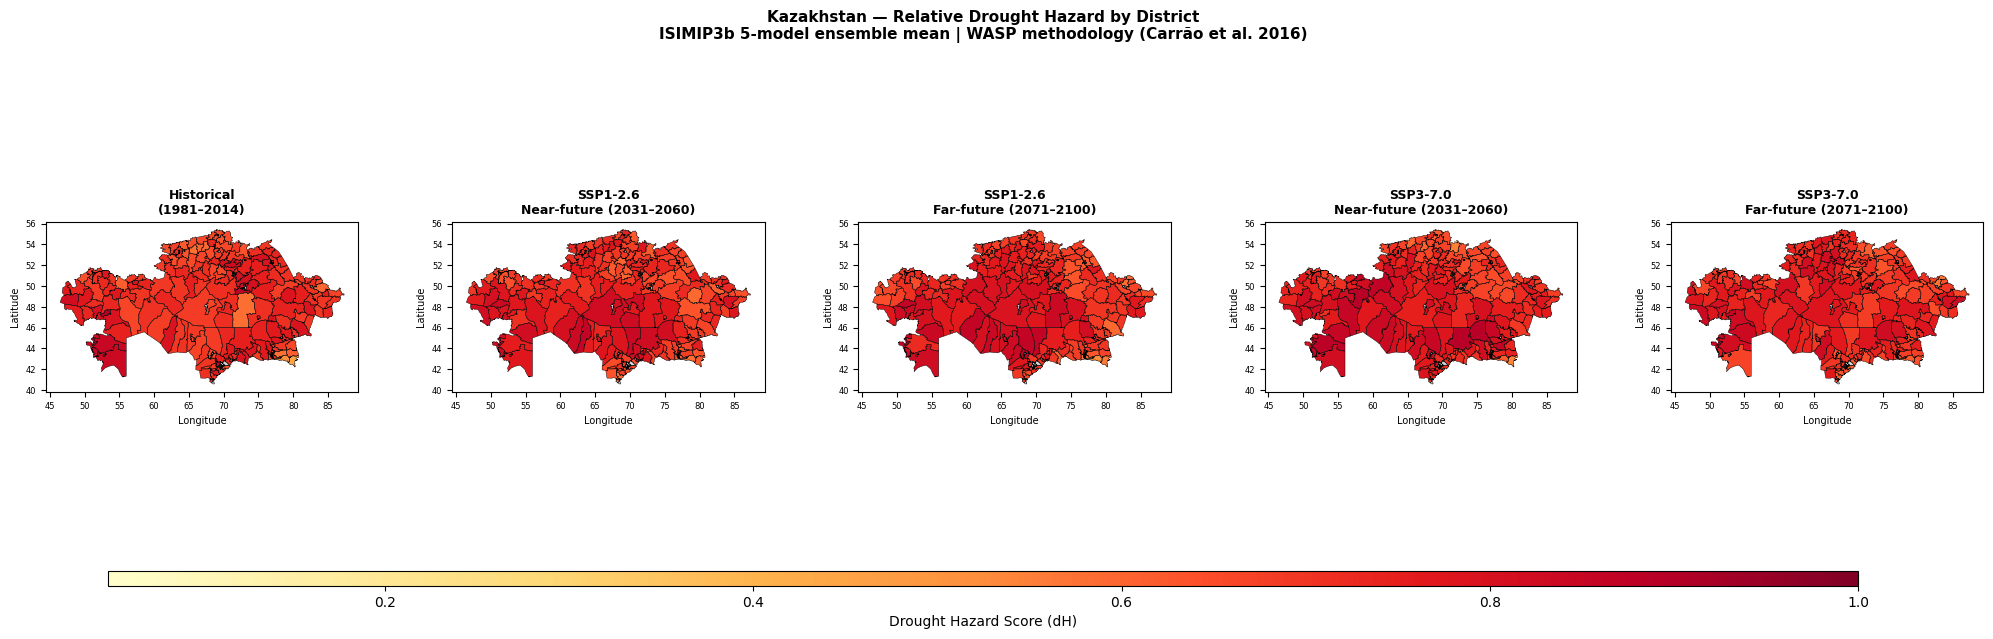

Map saved: data\isimip3b\processed\outputs_hazards\droughthazard_KZ_maps.png


In [11]:
if all_results:
    n_sc  = len(all_results)
    fig, axes = plt.subplots(1, n_sc, figsize=(5 * n_sc, 6))
    if n_sc == 1: axes = [axes]

    vmin, vmax = 0.05, 1.0
    cmap = 'YlOrRd'

    titles = {
        'historic':  'Historical\n(1981–2014)',
        'ssp126_nf': 'SSP1-2.6\nNear-future (2031–2060)',
        'ssp126_ff': 'SSP1-2.6\nFar-future (2071–2100)',
        'ssp370_nf': 'SSP3-7.0\nNear-future (2031–2060)',
        'ssp370_ff': 'SSP3-7.0\nFar-future (2071–2100)',
    }

    for ax, (lbl, result) in zip(axes, all_results.items()):
        plot_gdf = districts.copy()
        # Build composite key on the shapefile side to match result['district']
        plot_gdf['_key'] = plot_gdf['name_en'] + ' | ' + plot_gdf['oblast_en']
        plot_gdf['dH'] = plot_gdf['_key'].map(
            dict(zip(result['district'], result['hazard_raw']))
        )
        plot_gdf.plot(
            column='dH', ax=ax, cmap=cmap, vmin=vmin, vmax=vmax,
            legend=False,
            missing_kwds={'color': 'lightgrey', 'label': 'No grid coverage'}
        )
        plot_gdf.boundary.plot(ax=ax, color='black', linewidth=0.3)

        ax.set_title(titles.get(lbl, lbl), fontsize=9, fontweight='bold')
        ax.set_xlabel('Longitude', fontsize=7)
        ax.set_ylabel('Latitude', fontsize=7)
        ax.tick_params(labelsize=6)

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=mcolors.Normalize(vmin=vmin, vmax=vmax))
    sm.set_array([])
    fig.subplots_adjust(bottom=0.15, wspace=0.3)
    cbar_ax = fig.add_axes([0.15, 0.05, 0.7, 0.025])
    fig.colorbar(sm, cax=cbar_ax, orientation='horizontal',
                 label='Drought Hazard Score (dH)')

    fig.suptitle(
        'Kazakhstan — Relative Drought Hazard by District\n'
        'ISIMIP3b 5-model ensemble mean | WASP methodology (Carrão et al. 2016)',
        fontsize=11, fontweight='bold', y=1.01
    )

    map_path = OUTPUT_DIR / 'droughthazard_KZ_maps.png'
    plt.savefig(map_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Map saved: {map_path}')

## Conclusions

This workflow downloads ISIMIP3b precipitation data, clips it to Kazakhstan, aggregates it to districts, and computes drought hazard (dH) using the WASP methodology.

**Outputs saved to `data/isimip3b/processed/outputs_hazards/`:**

| File | Contents |
|---|---|
| `droughthazard_KZ_historic.csv` | dH + WASP diagnostics, historical 1981–2014 |
| `droughthazard_KZ_ssp126_nf.csv` | dH, SSP1-2.6 near-future 2031–2060 |
| `droughthazard_KZ_ssp126_ff.csv` | dH, SSP1-2.6 far-future 2071–2100 |
| `droughthazard_KZ_ssp370_nf.csv` | dH, SSP3-7.0 near-future 2031–2060 |
| `droughthazard_KZ_ssp370_ff.csv` | dH, SSP3-7.0 far-future 2071–2100 |
| `droughthazard_KZ_all_scenarios.csv` | All scenarios combined |

The `district` column in each output file contains composite keys of the form `"district_name | oblast_name"` (e.g. `"Almaty District | Almaty Oblast"`), used to uniquely identify districts that share names across different oblasts.

**Next step:** Use these dH scores as input to `Risk_assessment_RELATIVE_DROUGHT_KZ.ipynb` to compute drought risk as hazard × exposure × vulnerability.

## Contributors

Original CLIMAAX workflow developed by [Silvia Artuso](https://iiasa.ac.at/staff/silvia-artuso) and [Dor Fridman](https://iiasa.ac.at/staff/dor-fridman) from [IIASA's Water Security Research Group](https://iiasa.ac.at/programs/biodiversity-and-natural-resources-bnr/water-security), and supported by [Michaela Bachmann](https://iiasa.ac.at/staff/michaela-bachmann) from [IIASA's Systemic Risk and Resilience Research Group](https://iiasa.ac.at/programs/advancing-systems-analysis-asa/systemic-risk-and-resilience).

Kazakhstan adaptation based on direct ISIMIP3b download pipeline.

## References

[1] Carrão, H., Naumann, G., & Barbosa, P. (2016). Mapping global patterns of drought risk: An empirical framework based on sub-national estimates of hazard, exposure and vulnerability. *Global Environmental Change*, 39, 108–124. https://doi.org/10.1016/j.gloenvcha.2016.04.012

[2] Lange, S., et al. (2021). ISIMIP3b bias-adjusted atmospheric climate input data (v1.1). ISIMIP Repository. https://doi.org/10.48364/ISIMIP.842396.1

[3] Lyon, B., & Barnston, A.G. (2005). ENSO and the Spatial Extent of Interannual Precipitation Extremes in Tropical Land Areas. *Journal of Climate*, 18(23), 5095–5109. *(WASP index description)*